# SBC VS TARP (Two Moons)

In [1]:
import numpy as np
import random
from scipy import stats
import matplotlib.pyplot as plt
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.utils.torchutils import BoxUniform
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc, run_tarp, check_tarp
from sbi.analysis import sbc_rank_plot
from sbi.analysis import plot_tarp

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

## Two Moons

In [3]:
mean_radius = 0.1
sd_radius = 0.01
baseoffset = 0.25

prior_torch = BoxUniform(
    low=-1 * torch.ones(2), high=1 * torch.ones(2), device=torch_device
)

x_o = torch.tensor([0, 0], device=torch_device)
x_o = x_o.flatten()

x_o_numpy = x_o.cpu().numpy()

In [4]:
def simulator_torch(theta):
    theta = theta.reshape(-1)
    a = (torch.pi * (torch.rand(1) - 0.5)).to(torch_device)
    r = mean_radius + torch.randn(1, device=torch_device) * sd_radius
    p = torch.tensor(
        [r * torch.cos(a) + baseoffset, r * torch.sin(a)], device=torch_device
    )
    z0 = -torch.abs(theta[0] + theta[1]) / torch.sqrt(torch.tensor(2.0))
    z1 = (-theta[0] + theta[1]) / torch.sqrt(torch.tensor(2.0))
    return p + torch.tensor([z0, z1], device=torch_device)


def simulator_torch_batched(theta):
    n_sim, data_dim = theta.shape
    x_samples = torch.zeros((n_sim, data_dim))

    for i in range(n_sim):
        x_samples[i,] = simulator_torch(theta[i,])

    return x_samples


def simulator_numpy(theta):
    theta = theta.reshape(-1)
    a = np.array(np.pi * (np.random.random(1) - 0.5))
    r = mean_radius + np.random.normal(loc=0, scale=1, size=1) * sd_radius
    p = np.array([r * np.cos(a) + baseoffset, r * np.sin(a)])
    z0 = -np.abs(theta[0] + theta[1]) / np.sqrt(2.0)
    z1 = (-theta[0] + theta[1]) / np.sqrt(2.0)
    return p.reshape(-1) + np.array([z0, z1])


def analytic_posterior_numpy(x_o, n_samples=1):
    theta = np.zeros((n_samples, 2))
    for i in range(n_samples):
        p = simulator_numpy(np.zeros(2))
        q = np.zeros(2)
        q[0] = (p[0] - x_o[0]) * np.sqrt(2)
        q[1] = (x_o[1] - p[1]) * np.sqrt(2)

        if np.random.rand() < 0.5:
            q[0] = -q[0]

        theta[i, 0] = (q[0] - q[1]) / 2
        theta[i, 1] = (q[0] + q[1]) / 2
    return theta

In [5]:
set_seed(1)
num_posterior_samples=1000
simulation_budget = 10000

prior, num_parameters, prior_returns_numpy = process_prior(prior_torch)
simulator = process_simulator(simulator_torch, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

In [6]:
inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

In [7]:
theta, x = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=simulation_budget
)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:00<00:00, 10349.17it/s]


In [8]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500,
    learning_rate=0.0005
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 133 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-08-26T14_32_44.982812' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


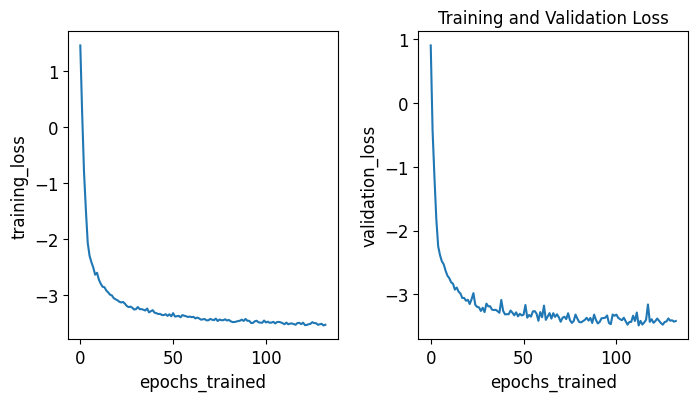

In [9]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [11]:
theta_trained = posterior.sample((num_posterior_samples,), x=x_o)
theta_trained = theta_trained.reshape((num_posterior_samples, 2))

1098it [00:00, 13003.06it/s]            


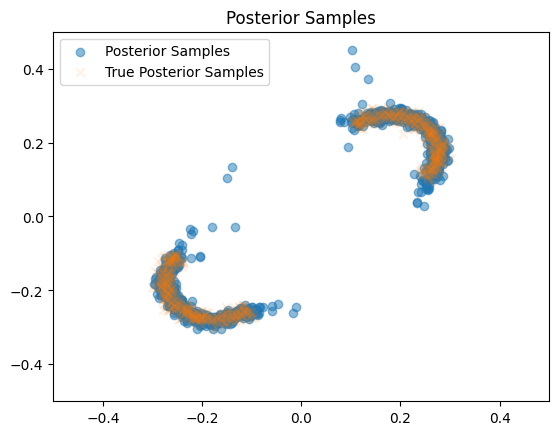

In [14]:
theta_true = analytic_posterior_numpy(x_o_numpy, n_samples=num_posterior_samples)

plt.scatter(theta_trained[:, 0], theta_trained[:, 1], alpha=0.5, label='Posterior Samples')
plt.scatter(theta_true[:, 0], theta_true[:, 1], alpha=0.1, marker='x', label='True Posterior Samples')
plt.title("Posterior Samples")
plt.xlim([-0.5, 0.5])
plt.ylim([-0.5, 0.5])
plt.legend()
plt.show()

In [15]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 8))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend(frameon=False)
    plt.show()

In [16]:
y_test_tensor, x_test_tensor = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=1000
)

100%|██████████| 1000/1000 [00:00<00:00, 9837.77it/s]


In [17]:
sbc_results = []
np.random.seed(100)
torch.manual_seed(100)
num_posterior_samples = 1000
parameter_labels = ["Dim 1", "Dim 2"]
ranks, dap_samples = run_sbc(
    y_test_tensor,
    x_test_tensor,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
    reject_outside_prior=False
)

stats_sbc = check_sbc(
    ranks, 
    y_test_tensor, 
    dap_samples, 
    num_posterior_samples=num_posterior_samples
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats_sbc
})

Sampling 1000 times (1000,) posterior samples.:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 1000 SBC samples: 100%|██████████| 1000/1000 [00:00<00:00, 20452.24it/s]


In [18]:
print(stats_sbc)

{'ks_pvals': tensor([0.0086, 0.1461]), 'c2st_ranks': tensor([0.6020, 0.5735], dtype=torch.float64), 'c2st_dap': tensor([0.4890, 0.4805], dtype=torch.float64)}


In [19]:
print("Kolmogorov-Smirnov Test Results (SBC):")
print("-" * 45)

num_dimensions = ranks.shape[1] 

for dim in range(num_dimensions):
    normalized_ranks = ranks[:, dim] / num_posterior_samples
    ks_stat, p_value = stats.kstest(normalized_ranks, 'uniform')
    
    print(f"Parameter:        {parameter_labels[dim]}")
    print(f"KS Statistic (D): {ks_stat:.4f}")
    print(f"p-value:          {p_value:.4e}")

    if p_value < 0.05:
        print("Status: MISCALIBRATED (reject null)")
    else:
        print("Status: CALIBRATED (fail to reject null)")
    print("-" * 45)

Kolmogorov-Smirnov Test Results (SBC):
---------------------------------------------
Parameter:        Dim 1
KS Statistic (D): 0.0520
p-value:          8.6379e-03
Status: MISCALIBRATED (reject null)
---------------------------------------------
Parameter:        Dim 2
KS Statistic (D): 0.0360
p-value:          1.4611e-01
Status: CALIBRATED (fail to reject null)
---------------------------------------------


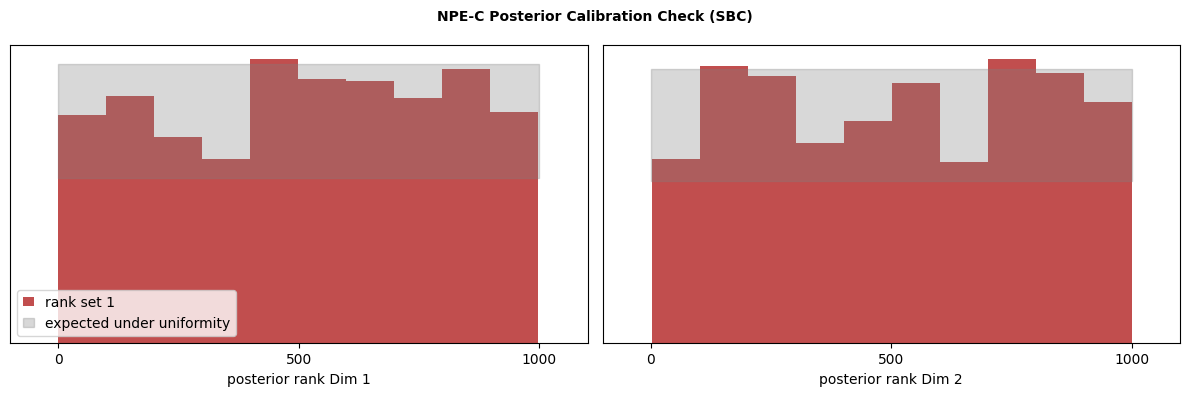

In [20]:
fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(12, 4),
    parameter_labels=parameter_labels
)

fig.suptitle('NPE-C Posterior Calibration Check (SBC)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_28568\1800669780.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ranks_np = np.array(ranks)


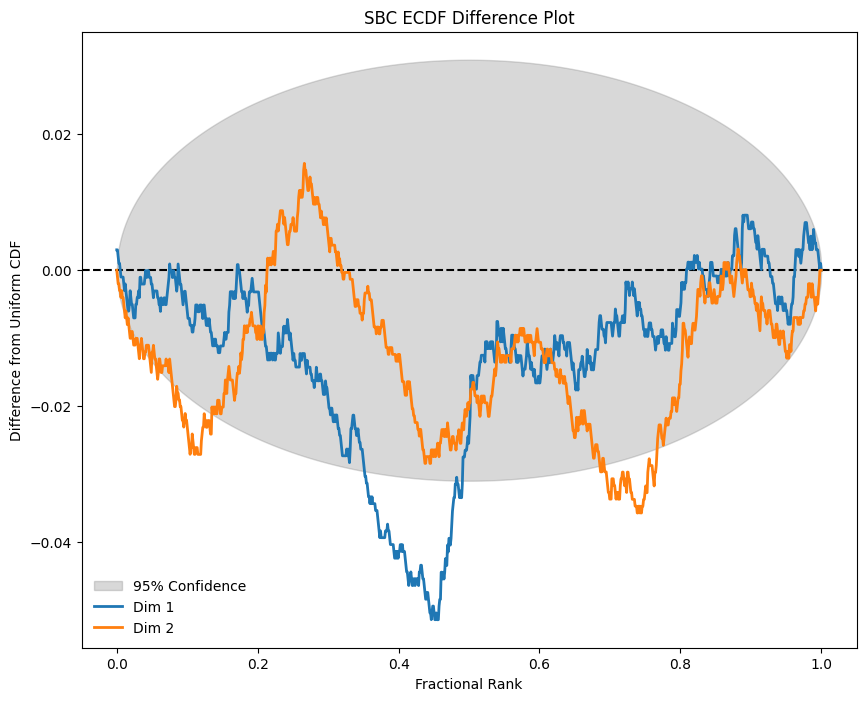

In [21]:
plot_sbc_ecdf_diff(ranks, num_posterior_samples=1000,
                   param_names=parameter_labels)

In [22]:
tarp_results = []
np.random.seed(100)
torch.manual_seed(100)
ecp, alpha = run_tarp(
    y_test_tensor,
    x_test_tensor,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False
)

Sampling 1000 times (1000,) posterior samples.: 100%|██████████| 1000/1000 [00:24<00:00, 41.05it/s]


In [23]:
stats_tarp = check_tarp(
    ecp,
    alpha
)

tarp_results.append({
    "ecp": ecp,
    "alpha": alpha,
    "stats": stats_tarp
})

In [24]:
print(stats_tarp)

(-0.0030100299045443535, np.float64(0.9999999999971402))


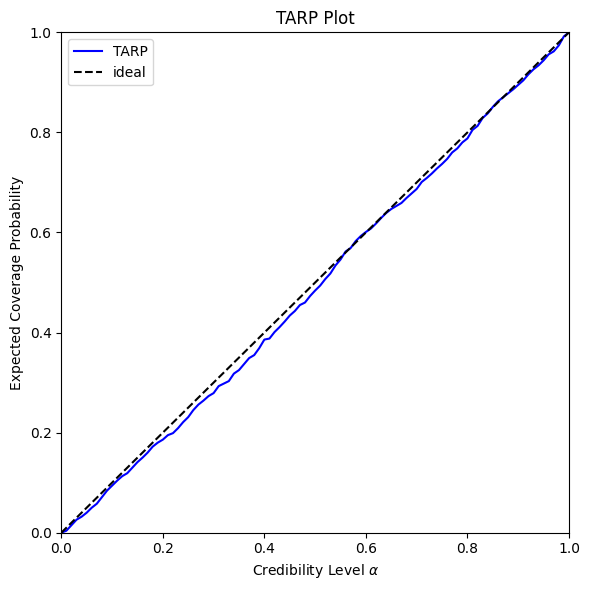

In [25]:
fig, ax = plot_tarp(
    ecp, 
    alpha,
    title="TARP Plot"
)

plt.tight_layout()
plt.show()